# Exploratory Data Analysis
This notebook explores the cleaned WritingPrompts dataset (25k subset).
We analyze story counts, word count distribution, and basic vocabulary metrics.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set standard styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [6]:
import os
# Load Cleaned Data
path1 = '../data/processed/writing_prompts_full_cleaned.parquet'
path2 = 'data/processed/writing_prompts_full_cleaned.parquet'
file_path = path1 if os.path.exists(path1) else path2

df = pd.read_parquet(file_path)
print(f"Loaded {len(df)} stories.")
df.head(2)


Loaded 272579 stories.


,prompt,story,clean_story,clean_prompt
0,[ WP ] You 've finally managed to discover the...,"So many times have I walked on ruins, the rema...","So many times have I walked on ruins, the rema...",You 've finally managed to discover the secret...
1,"[ WP ] The moon is actually a giant egg , and ...","-Week 18 aboard the Depth Reaver, Circa 2023- ...","-Week 18 aboard the Depth Reaver, Circa 2023- ...","The moon is actually a giant egg , and it has ..."


In [7]:
# Calculate Word Counts
df['story_word_count'] = df['clean_story'].apply(lambda x: len(str(x).split()))
df['prompt_word_count'] = df['clean_prompt'].apply(lambda x: len(str(x).split()))

print("Story Word Count Stats:")
print(df['story_word_count'].describe())


Story Word Count Stats:
count    272579.000000
mean        552.644918
std         377.808515
min         100.000000
25%         269.000000
50%         454.000000
75%         730.000000
max        6980.000000
Name: story_word_count, dtype: float64


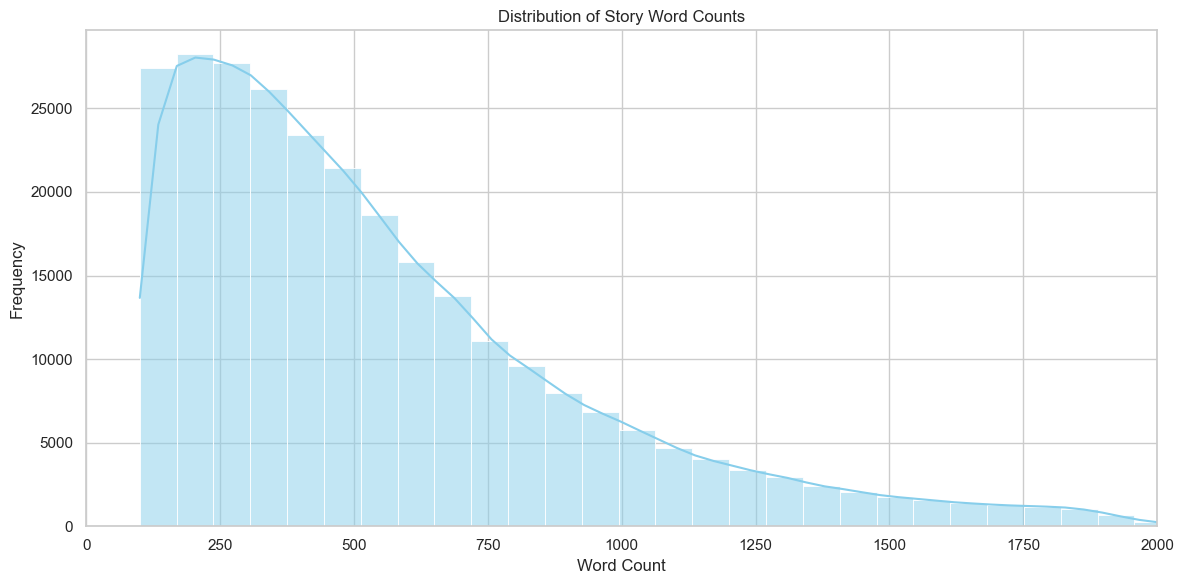

In [8]:
# Plot Story Word Count Distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['story_word_count'], bins=100, kde=True, color='skyblue')
plt.title('Distribution of Story Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, 2000)  # focusing on the core distribution
plt.tight_layout()
plt.show()
